In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Web Scraper

In [4]:
from bs4 import BeautifulSoup
import requests

Require input is the URL.

In [ ]:
url = 'https://www.britannica.com/topic/list-of-state-capitals-in-the-United-States-2119210'
page = requests.get(url)
soup = BeautifulSoup(page.text, 'html')
print(soup)

<!DOCTYPE html>
<html class="topic-desktop ui-unknown0 ui-unknown" lang="en">
<head prefix="og: https://ogp.me/ns# fb: https://ogp.me/ns/fb#">
<meta charset="utf-8"/>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<link href="https://cdn.britannica.com/mendel-resources/3-148" rel="dns-prefetch"/>
<link href="https://cdn.britannica.com/mendel-resources/3-148" rel="preconnect"/>
<link as="script" href="https://www.googletagservices.com/tag/js/gpt.js" rel="preload"/>
<link href="/favicon.png" rel="icon"/>
<meta content="This is a list of the cities that are state capitals in the United States, ordered alphabetically by state. The list also provides the most recent U.S. census population for each city as well as an estimated population. (This list does not include the capital of the United States, Washington, D.C.)" name="description"/>
<meta content="list of state capitals in the United States, e

Find all tables in the page. In this website, though, there's only one so it's simple.

In [ ]:
soup.find_all('table')

[<table data-sortable-table="true"> <thead> <tr> <th data-col-type="text" data-sortable-type="alpha">state</th> <th data-col-type="text" data-sortable-type="alpha">capital</th> <th data-col-type="number" data-sortable-type="numeric">population of capital: census</th> <th data-col-type="number" data-sortable-type="numeric">population of capital: estimated</th> </tr> </thead> <tbody> <tr> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td> <td>(2020) 200,603</td> <td>(2021 est.) 198,665</td> </tr> <tr> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alaska">Alaska</a></td> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Juneau">Juneau</a></td> <td>(2020) 32,255</td>

Let's first get just the title of the table.

*Note: `<th>` tag defines a header cell in an HTML table*

In [ ]:
titles = soup.find_all('th')
titles

[<th data-col-type="text" data-sortable-type="alpha">state</th>,
 <th data-col-type="text" data-sortable-type="alpha">capital</th>,
 <th data-col-type="number" data-sortable-type="numeric">population of capital: census</th>,
 <th data-col-type="number" data-sortable-type="numeric">population of capital: estimated</th>]

Since we do not need the tags, let's clean up the data.

In [ ]:
titles_list = [title.text for title in titles]
titles_list

['state',
 'capital',
 'population of capital: census',
 'population of capital: estimated']

If the output still contains newline and other symbols that are not needed, you can further clean the data using, for example, ```.strip()```

Next, create a dataframe

In [ ]:
import pandas as pd

df = pd.DataFrame(columns = titles_list)
df

,state,capital,population of capital: census,population of capital: estimated


Let's scrape the remaining data and fill this table!

In [ ]:
rows = soup.find_all('tr')
len(rows)

51

The data of our interest are within the scope of **td** tags.

*Note: `<td>` tag defines a standard data cell in an HTML table.*

In [ ]:
# -- Long version --
# row_data = []
# for row in rows:
#   row_data.append(row.find_all('td'))

# -- Short version --
row_data = [row.find_all('td') for row in rows]
row_data

[[],
 [<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td>,
  <td>(2020) 200,603</td>,
  <td>(2021 est.) 198,665</td>],
 [<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alaska">Alaska</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Juneau">Juneau</a></td>,
  <td>(2020) 32,255</td>,
  <td>(2021 est.) 31,973</td>],
 [<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Arizona-state">Arizona</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Phoenix-Arizona">Phoenix</a></td>,
  <td>(2020) 1,608,139</td>,
  <td>(2021 est.) 1,624,569</td>],
 [<

The first row collected has no value, thus an empty list.

In [ ]:
row_data[0]

[]

Turns out the first row is actually here

In [ ]:
row_data[1]

[<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td>,
 <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td>,
 <td>(2020) 200,603</td>,
 <td>(2021 est.) 198,665</td>]

However, we only want the text portion.

In [ ]:
print(row_data[1][0].text)
print(row_data[1][1].text)
print(row_data[1][2].text)
print(row_data[1][3].text)

Alabama
Montgomery
(2020) 200,603
(2021 est.) 198,665


Therefore, more cleaning is necessary.

Add the remaining rows to the dataframe.

But does this code work?

In [ ]:
for each_row_data in row_data[1:]:
  state=[]
  for each_row_data_elem in each_row_data:
    state.append(each_row_data_elem.text)

  length = len(df)
  df.loc[length] = state

In [ ]:
df

,state,capital,population of capital: census,population of capital: estimated
0,Alabama,Montgomery,"(2020) 200,603","(2021 est.) 198,665"
1,Alaska,Juneau,"(2020) 32,255","(2021 est.) 31,973"
2,Arizona,Phoenix,"(2020) 1,608,139","(2021 est.) 1,624,569"
3,Arkansas,Little Rock,"(2020) 202,591","(2021 est.) 201,998"
4,California,Sacramento,"(2020) 524,943","(2021 est.) 525,041"
...,...,...,...,...
145,Virginia,Richmond,"(2020) 226,610","(2021 est.) 226,604"
146,Washington,Olympia,"(2020) 55,605","(2021 est.) 55,919"
147,West Virginia,Charleston,"(2020) 48,864","(2021 est.) 48,018"
148,Wisconsin,Madison,"(2020) 269,840","(2021 est.) 269,196"


TODO:

- Scrape other table from wikipedia
- Generate a new table/tables using dataframe
- Feel free to use other html tags
- Clean & preprocess

---

Other websites (for instance)
- https://www.timesjobs.com/
- https://www.tripadvisor.com/

---

In [ ]:
url = 'https://en.wikipedia.org/wiki/John_F._Kennedy_assassination_conspiracy_theories'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
page = requests.get(url, headers=headers)
soup = BeautifulSoup(page.text, 'html')
print(soup)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>John F. Kennedy assassination conspiracy theories - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limit

In [34]:
soup.find_all('table')

[<table class="nowraplinks hlist mw-collapsible autocollapse navbox-inner" style="border-spacing:0;background:transparent;color:inherit"><tbody><tr><th class="navbox-title" colspan="2" scope="col"><link href="mw-data:TemplateStyles:r1129693374" rel="mw-deduplicated-inline-style"/><style data-mw-deduplicate="TemplateStyles:r1239400231">.mw-parser-output .navbar{display:inline;font-size:88%;font-weight:normal}.mw-parser-output .navbar-collapse{float:left;text-align:left}.mw-parser-output .navbar-boxtext{word-spacing:0}.mw-parser-output .navbar ul{display:inline-block;white-space:nowrap;line-height:inherit}.mw-parser-output .navbar-brackets::before{margin-right:-0.125em;content:"[ "}.mw-parser-output .navbar-brackets::after{margin-left:-0.125em;content:" ]"}.mw-parser-output .navbar li{word-spacing:-0.125em}.mw-parser-output .navbar a>span,.mw-parser-output .navbar a>abbr{text-decoration:inherit}.mw-parser-output .navbar-mini abbr{font-variant:small-caps;border-bottom:none;text-decoration

In [36]:
titles = soup.find_all('th')
titles

[<th class="navbox-title" colspan="2" scope="col"><link href="mw-data:TemplateStyles:r1129693374" rel="mw-deduplicated-inline-style"/><style data-mw-deduplicate="TemplateStyles:r1239400231">.mw-parser-output .navbar{display:inline;font-size:88%;font-weight:normal}.mw-parser-output .navbar-collapse{float:left;text-align:left}.mw-parser-output .navbar-boxtext{word-spacing:0}.mw-parser-output .navbar ul{display:inline-block;white-space:nowrap;line-height:inherit}.mw-parser-output .navbar-brackets::before{margin-right:-0.125em;content:"[ "}.mw-parser-output .navbar-brackets::after{margin-left:-0.125em;content:" ]"}.mw-parser-output .navbar li{word-spacing:-0.125em}.mw-parser-output .navbar a>span,.mw-parser-output .navbar a>abbr{text-decoration:inherit}.mw-parser-output .navbar-mini abbr{font-variant:small-caps;border-bottom:none;text-decoration:none;cursor:inherit}.mw-parser-output .navbar-ct-full{font-size:114%;margin:0 7em}.mw-parser-output .navbar-ct-mini{font-size:114%;margin:0 4em}ht

In [37]:
titles_list = [title.text for title in titles]
titles_list

['vteAssassination of John F. Kennedy',
 'Assassination',
 'Aftermath',
 'State funeral',
 'Investigations',
 'Related',
 'vteConspiracy theories',
 'Overview',
 'Core topics',
 'Psychology',
 'Astronomy and outer space',
 'UFOs(Alleged aliens)',
 'Hoaxes',
 'Deaths and disappearances',
 'Assassination / suicide theories',
 'Accidents / disasters',
 'Other cases',
 'Body double hoax',
 'Energy, environment',
 'United States',
 'False flag allegations',
 'Gender and sexuality',
 'Health',
 'Race, religion and/or ethnicity',
 'Antisemitic',
 'Christian',
 'Anti-Christian',
 'Islamophobic',
 'Genocide denial /Denial of mass killings',
 'Regional',
 'Asia',
 'Americas(outside the United States)',
 'Middle East / North Africa',
 'Russia',
 'Turkey',
 'Other European',
 'United States',
 '2020 election',
 'Other',
 'Pseudolaw',
 'Satirical',
 'See also']

In [38]:
df = pd.DataFrame(columns = titles_list)
df

,vteAssassination of John F. Kennedy,Assassination,Aftermath,State funeral,Investigations,Related,vteConspiracy theories,Overview,Core topics,Psychology,...,Middle East / North Africa,Russia,Turkey,Other European,United States,2020 election,Other,Pseudolaw,Satirical,See also


In [41]:
soup.find_all('tr')

[<tr><th class="navbox-title" colspan="2" scope="col"><link href="mw-data:TemplateStyles:r1129693374" rel="mw-deduplicated-inline-style"/><style data-mw-deduplicate="TemplateStyles:r1239400231">.mw-parser-output .navbar{display:inline;font-size:88%;font-weight:normal}.mw-parser-output .navbar-collapse{float:left;text-align:left}.mw-parser-output .navbar-boxtext{word-spacing:0}.mw-parser-output .navbar ul{display:inline-block;white-space:nowrap;line-height:inherit}.mw-parser-output .navbar-brackets::before{margin-right:-0.125em;content:"[ "}.mw-parser-output .navbar-brackets::after{margin-left:-0.125em;content:" ]"}.mw-parser-output .navbar li{word-spacing:-0.125em}.mw-parser-output .navbar a>span,.mw-parser-output .navbar a>abbr{text-decoration:inherit}.mw-parser-output .navbar-mini abbr{font-variant:small-caps;border-bottom:none;text-decoration:none;cursor:inherit}.mw-parser-output .navbar-ct-full{font-size:114%;margin:0 7em}.mw-parser-output .navbar-ct-mini{font-size:114%;margin:0 4e

In [39]:
rows = soup.find_all('tr')
len(rows)

67

In [40]:
row_data = [row.find_all('td') for row in rows]
row_data

[[],
 [<td class="navbox-abovebelow" colspan="2"><div>
  <ul><li><a href="/wiki/John_F._Kennedy" title="John F. Kennedy">John F. Kennedy</a></li>
  <li><a href="/wiki/Lee_Harvey_Oswald" title="Lee Harvey Oswald">Lee Harvey Oswald</a></li></ul>
  </div></td>],
 [<td class="navbox-list-with-group navbox-list navbox-odd" style="width:100%;padding:0"><div style="padding:0 0.25em">
  <ul><li><a href="/wiki/John_F._Kennedy_assassination_rifle" title="John F. Kennedy assassination rifle">Assassination rifle</a></li>
  <li><a href="/wiki/Timeline_of_the_John_F._Kennedy_assassination" title="Timeline of the John F. Kennedy assassination">Timeline</a></li>
  <li><a href="/wiki/J._D._Tippit" title="J. D. Tippit">J. D. Tippit</a></li>
  <li><a href="/wiki/John_Connally" title="John Connally">John Connally</a></li>
  <li><a href="/wiki/Nellie_Connally" title="Nellie Connally">Nellie Connally</a></li>
  <li><a href="/wiki/Jacqueline_Kennedy_Onassis" title="Jacqueline Kennedy Onassis">Jacqueline Kenn

In [42]:
row_data[0]

[]

In [43]:
row_data[1]

[<td class="navbox-abovebelow" colspan="2"><div>
 <ul><li><a href="/wiki/John_F._Kennedy" title="John F. Kennedy">John F. Kennedy</a></li>
 <li><a href="/wiki/Lee_Harvey_Oswald" title="Lee Harvey Oswald">Lee Harvey Oswald</a></li></ul>
 </div></td>]

In [ ]:
tables = soup.find_all('table')
print(f"Found {len(tables)} tables on the page.")

Found 24 tables on the page.


In [ ]:
header = soup.find_all('h1')
header

[<h1 class="firstHeading mw-first-heading" id="firstHeading"><span class="mw-page-title-main">John F. Kennedy assassination conspiracy theories</span></h1>]

**Topic name is John F. Kennedy assassination conspiracy theories.**

In [ ]:
# Find all div elements with the specified classes
div_headings_2 = soup.find_all('div', class_='mw-heading mw-heading2')
div_headings_3 = soup.find_all('div', class_='mw-heading mw-heading3')
div_headings_4 = soup.find_all('div', class_='mw-heading mw-heading4')

# Iterate through mw-heading2 elements
for h2_div in div_headings_2:
    h2_text = h2_div.text.strip()
    print(f"## {h2_text}")

    # Find all subsequent sibling elements of the current h2_div
    for sibling in h2_div.find_next_siblings():
        # Check if the sibling is an mw-heading3 div
        if sibling.name == 'div' and 'mw-heading3' in sibling.get('class', []):
            h3_text = sibling.text.strip()
            print(f"  ### {h3_text}")
        # Stop when the next mw-heading2 div is found
        elif sibling.name == 'div' and 'mw-heading2' in sibling.get('class', []):
            break
        elif sibling.name == 'div' and 'mw-heading4' in sibling.get('class', []):
            h4_text = sibling.text.strip()
            print(f"    #### {h4_text}")


## Background
  ### Public opinion
  ### Views of those close to Kennedy
## Circumstantial evidence of a cover-up
  ### Background
  ### Alleged inconsistencies
## Allegations of witness tampering, intimidation, and foul play
  ### Alleged witness intimidation
  ### Witness deaths
## Allegations of evidence suppression, tampering, and fabrication
  ### Suppression of evidence
    #### Ignored testimony
    #### Confiscated film and photographs
    #### Withheld documents
  ### Tampering with evidence
    #### Photographs
    #### Zapruder film
    #### Kennedy's body
  ### Fabrication of evidence
    #### Murder weapon
    #### Bullets and cartridges
## Allegations of multiple gunmen
  ### Number of shots
  ### Origin of the shots
  ### Testimony of witnesses
  ### Physical evidence
  ### Film and photographic evidence
  ### Acoustical evidence
  ### Medical evidence
  ### Oswald's marksmanship
  ### Role of Oswald
  ### Alternative gunmen
  ### Three tramps
## Allegations of other con

In [47]:
data_for_df = []
current_h2 = None
current_h3 = None
current_h4 = None
content = []

# Find all relevant elements (headings and content)
elements = soup.find_all(['div', 'p', 'ul', 'ol'])

for element in elements:
    if element.name == 'div' and 'mw-heading2' in element.get('class', []):
        # When a new H2 is found, save the content collected so far
        if content:
            data_for_df.append({'Level 2 Heading': current_h2, 'Level 3 Heading': current_h3, 'Level 4 Heading': current_h4, 'Content': "\n".join(content)})
        current_h2 = element.text.strip()
        current_h3 = None
        current_h4 = None
        content = []
    elif element.name == 'div' and 'mw-heading3' in element.get('class', []) and current_h2:
        # When a new H3 is found under an H2, save the content collected so far
        if content:
            data_for_df.append({'Level 2 Heading': current_h2, 'Level 3 Heading': current_h3, 'Level 4 Heading': current_h4, 'Content': "\n".join(content)})
        current_h3 = element.text.strip()
        current_h4 = None
        content = []
    elif element.name == 'div' and 'mw-heading4' in element.get('class', []) and current_h2 and current_h3:
        # When a new H4 is found under an H3, save the content collected so far
        if content:
            data_for_df.append({'Level 2 Heading': current_h2, 'Level 3 Heading': current_h3, 'Level 4 Heading': current_h4, 'Content': "\n".join(content)})
        current_h4 = element.text.strip()
        content = []
    elif element.name in ['p', 'ul', 'ol']:
        # Collect content elements
        content.append(element.text.strip())

# After the loop, add any remaining content
if content:
    data_for_df.append({'Level 2 Heading': current_h2, 'Level 3 Heading': current_h3, 'Level 4 Heading': current_h4, 'Content': "\n".join(content)})

# Create the DataFrame
df_wiki_content = pd.DataFrame(data_for_df)

# Fill any None values in heading columns with the previous heading value for better readability
df_wiki_content['Level 2 Heading'] = df_wiki_content['Level 2 Heading'].ffill()
df_wiki_content['Level 3 Heading'] = df_wiki_content['Level 3 Heading'].ffill()


display(df_wiki_content)

,Level 2 Heading,Level 3 Heading,Level 4 Heading,Content
0,None,None,None,Main pageContentsCurrent eventsRandom articleA...
1,Background,None,None,"On November 22, 1963, President John F. Kenned..."
2,Background,Public opinion,None,"According to John C. McAdams, ""The greatest an..."
3,Background,Views of those close to Kennedy,None,"Kennedy's youngest brother, Ted Kennedy, wrote..."
4,Circumstantial evidence of a cover-up,Background,None,"After Oswald's death, FBI Director J. Edgar Ho..."
...,...,...,...,...
59,Notable supporters and critics of JFK assassin...,Critics,None,Gerald Posner - investigative journalist\nJohn...
60,See also,Critics,None,Conspiracy theories in United States politics\...
61,Notes,Critics,None,^ The Warren Commission never asked Reynolds w...
62,References,Critics,None,"^ ""Findings"". Report of the Select Committee o..."


Years mentioned in the text:
Total years found: 1006
Most frequently mentioned years:
  2013: 68 times
  1963: 62 times
  1964: 45 times
  2007: 39 times
  2012: 33 times
  2010: 32 times
  1979: 30 times
  2022: 30 times
  2021: 28 times
  2003: 25 times


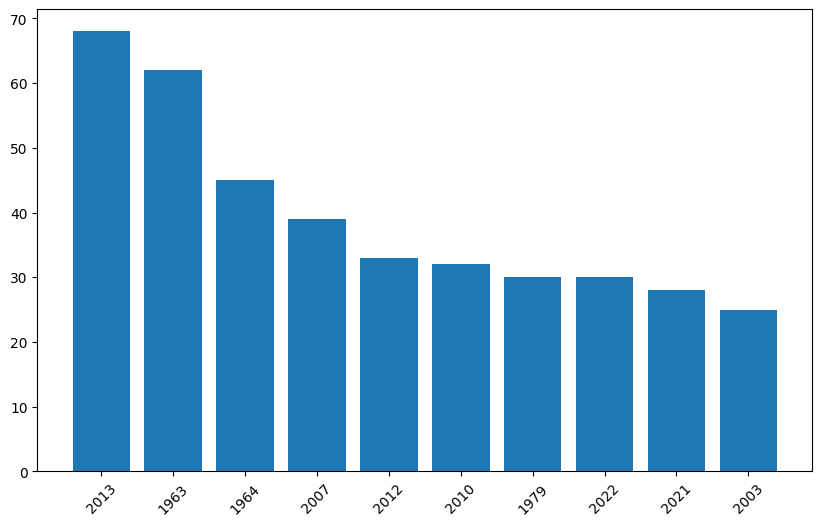

In [62]:
import regex as re
from collections import Counter

# Extract all text from the soup object
main_text = soup.get_text()

# 1. Extract years and dates
years_pattern = r'\b(1[0-9]{3}|20[0-9]{2})\b'  # Years from 1000-2099
years = re.findall(years_pattern, main_text)
years_counter = Counter(years)

print("Years mentioned in the text:")
print(f"Total years found: {len(years)}")
print("Most frequently mentioned years:")
for year, count in years_counter.most_common(10):
    print(f"  {year}: {count} times")

# Plot a bar chart of the most common years
most_common_years = dict(years_counter.most_common(10))
plot_len_bar(most_common_years, 45, (10, 6))

Most frequently mentioned names:
  Warren Commission: 114 times
  New York: 50 times
  President Kennedy: 49 times
  New Orleans: 38 times
  United States: 34 times
  Lee Harvey: 34 times
  Secret Service: 33 times
  House Select: 29 times
  Select Committee: 29 times
  Retrieved January: 25 times
  Book Depository: 22 times
  Retrieved September: 22 times
  Review Board: 21 times
  Retrieved December: 21 times
  Assassination Records: 20 times


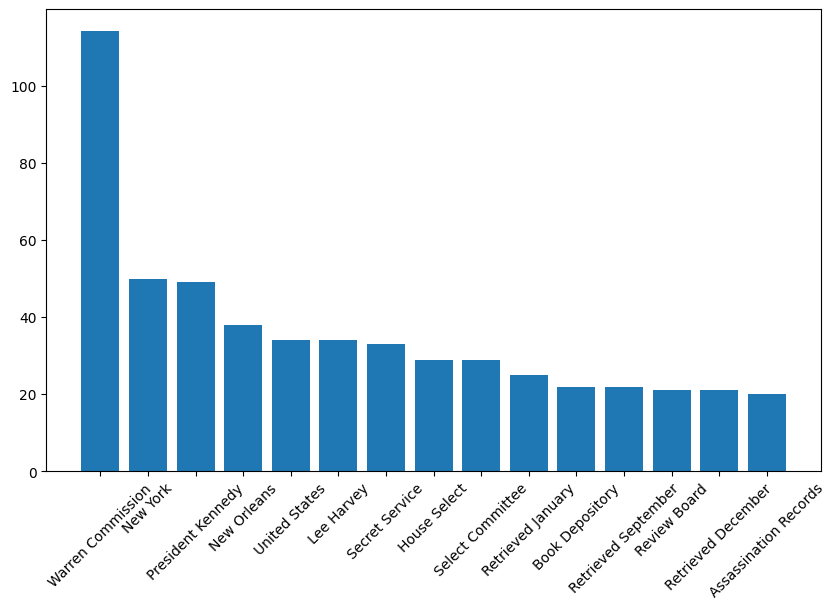

In [63]:
# 2. Extract Names
names_pattern = r'\b[A-Z][a-z]+\s+[A-Z][a-z]+\b'
potential_names = re.findall(names_pattern, main_text)

names = [name for name in potential_names]
names_counter = Counter(names)

print("Most frequently mentioned names:")
for name, count in names_counter.most_common(15):
    print(f"  {name}: {count} times")

# Plot a bar chart of the most common names
most_common_names = dict(names_counter.most_common(15))
plot_len_bar(most_common_names, 45, (10, 6))

Most frequently mentioned locations:
  World: 11 times
  America: 9 times
  Atlantic: 4 times
  Russia: 4 times
  world: 4 times
  France: 3 times
  Earth: 3 times
  Atlantic Monthly: 2 times
  England: 2 times
  Ancient: 1 times
  India
Cow: 1 times
  Africa
In: 1 times
  America Believe: 1 times
  Britain: 1 times
  Spain
Mano Negra: 1 times


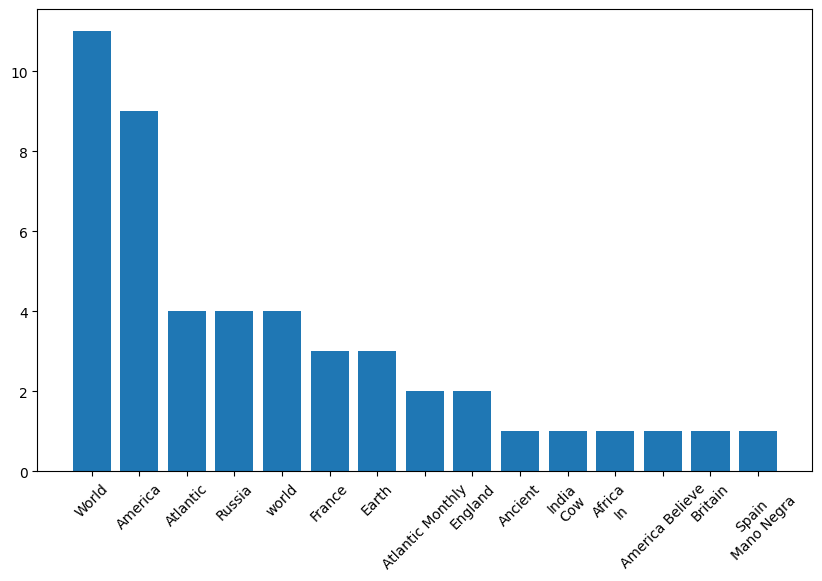

In [66]:
# 3. Extract locations
places_pattern = r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*(?:\s+(?:City|State|County|Country|Island|Sea|Ocean|Continent|Mountains?|River|Lake))?'

# More specific patterns for common geographical terms
geo_terms = ['Ancient', 'Greece', 'Egypt', 'Babylon', 'China', 'India', 'Europe', 'Asia', 'Africa',
             'America', 'Australia', 'Antarctica', 'Arctic', 'Atlantic', 'Pacific', 'Mediterranean',
             'England', 'Britain', 'France', 'Germany', 'Italy', 'Spain', 'Russia', 'Japan']

places = []
for term in geo_terms:
    pattern = rf'\b{term}(?:\s+[A-Z][a-z]+)*\b'
    found_places = re.findall(pattern, main_text)
    places.extend(found_places)

# Also extract standalone capitalized location words
standalone_places = re.findall(r'\b(?:Earth|Globe|World|Planet|Sphere|Disk|Circle)\b', main_text, re.IGNORECASE)
places.extend(standalone_places)

places_counter = Counter(places)

print("Most frequently mentioned locations:")
for place, count in places_counter.most_common(15):
    print(f"  {place}: {count} times")

# Plot a bar chart of the most common locations
most_common_places = dict(places_counter.most_common(15))
plot_len_bar(most_common_places, 45, (10, 6))

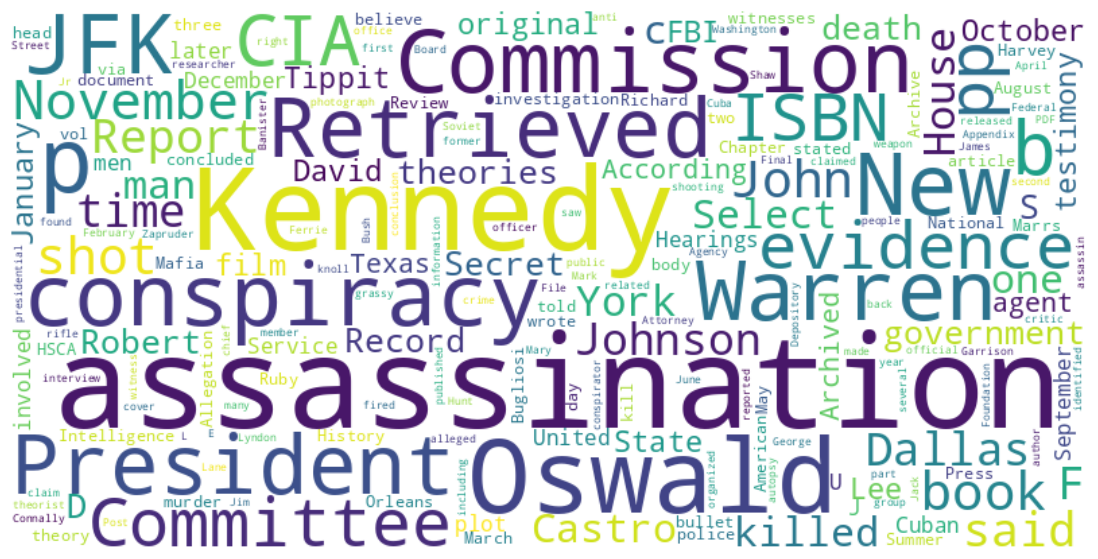

In [68]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 3: Extract all text
text = soup.get_text()
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()